In [1]:
import pickle
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [2]:
weight_trials = [1, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 17, 18, 22, 23, 24, 27, 28, 29, 30, 33, 35, 36, 38, 39, 40, 41, 42, 43, 45, 47, 49]


seeds = [1111,2222,3333]
seeds_lora = [1111,2222,3333, 4444,5555]

time_interval = [80000000,100000000]

In [3]:
with open("/home/fr/fr_lr554/samplefactory/sample-factory/sf_workingdir_lilly/dmlab/analysis/data/sim44_new.pkl", "rb") as f:
    all_results = pickle.load(f)

with open("/home/fr/fr_lr554/samplefactory/sample-factory/sf_workingdir_lilly/dmlab/analysis/data/sim47.pkl", "rb") as f:
    all_results_lora = pickle.load(f)

In [4]:
mean_results = dict()

for trial in weight_trials:
    mean_results_by_seeds = {1111:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None}, 
                2222:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None}, 
                3333:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None}}
    for seed in seeds:
        mean_results_by_seeds[seed]['raw_score'] = all_results[trial][seed]['raw_score'].mean(axis=1)
        mean_results_by_seeds[seed]['lenweighted_score'] = all_results[trial][seed]['lenweighted_score'].mean(axis=1)
        mean_results_by_seeds[seed]['reward_min'] = all_results[trial][seed]['reward_min'].mean(axis=1)
        mean_results_by_seeds[seed]['len'] = all_results[trial][seed]['len'].mean(axis=1)
    mean_results[trial] = mean_results_by_seeds

In [5]:
mean_results_lora = dict()

for trial in weight_trials:
    mean_results_by_seeds = {1111:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None}, 
                2222:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None}, 
                3333:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None},
                4444:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None},
                5555:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None}}
    for seed in seeds_lora:
        raw = all_results_lora[trial][seed]['raw_score']
        if raw is not None:
            mean_results_by_seeds[seed]['raw_score'] = raw.mean(axis=1)

        lw = all_results_lora[trial][seed]['lenweighted_score']
        if lw is not None:
            mean_results_by_seeds[seed]['lenweighted_score'] = lw.mean(axis=1)

        rmin = all_results_lora[trial][seed]['reward_min']
        if rmin is not None:
            mean_results_by_seeds[seed]['reward_min'] = rmin.mean(axis=1)

        l = all_results_lora[trial][seed]['len']
        if l is not None:
            mean_results_by_seeds[seed]['len'] = l.mean(axis=1)
    mean_results_lora[trial] = mean_results_by_seeds
    

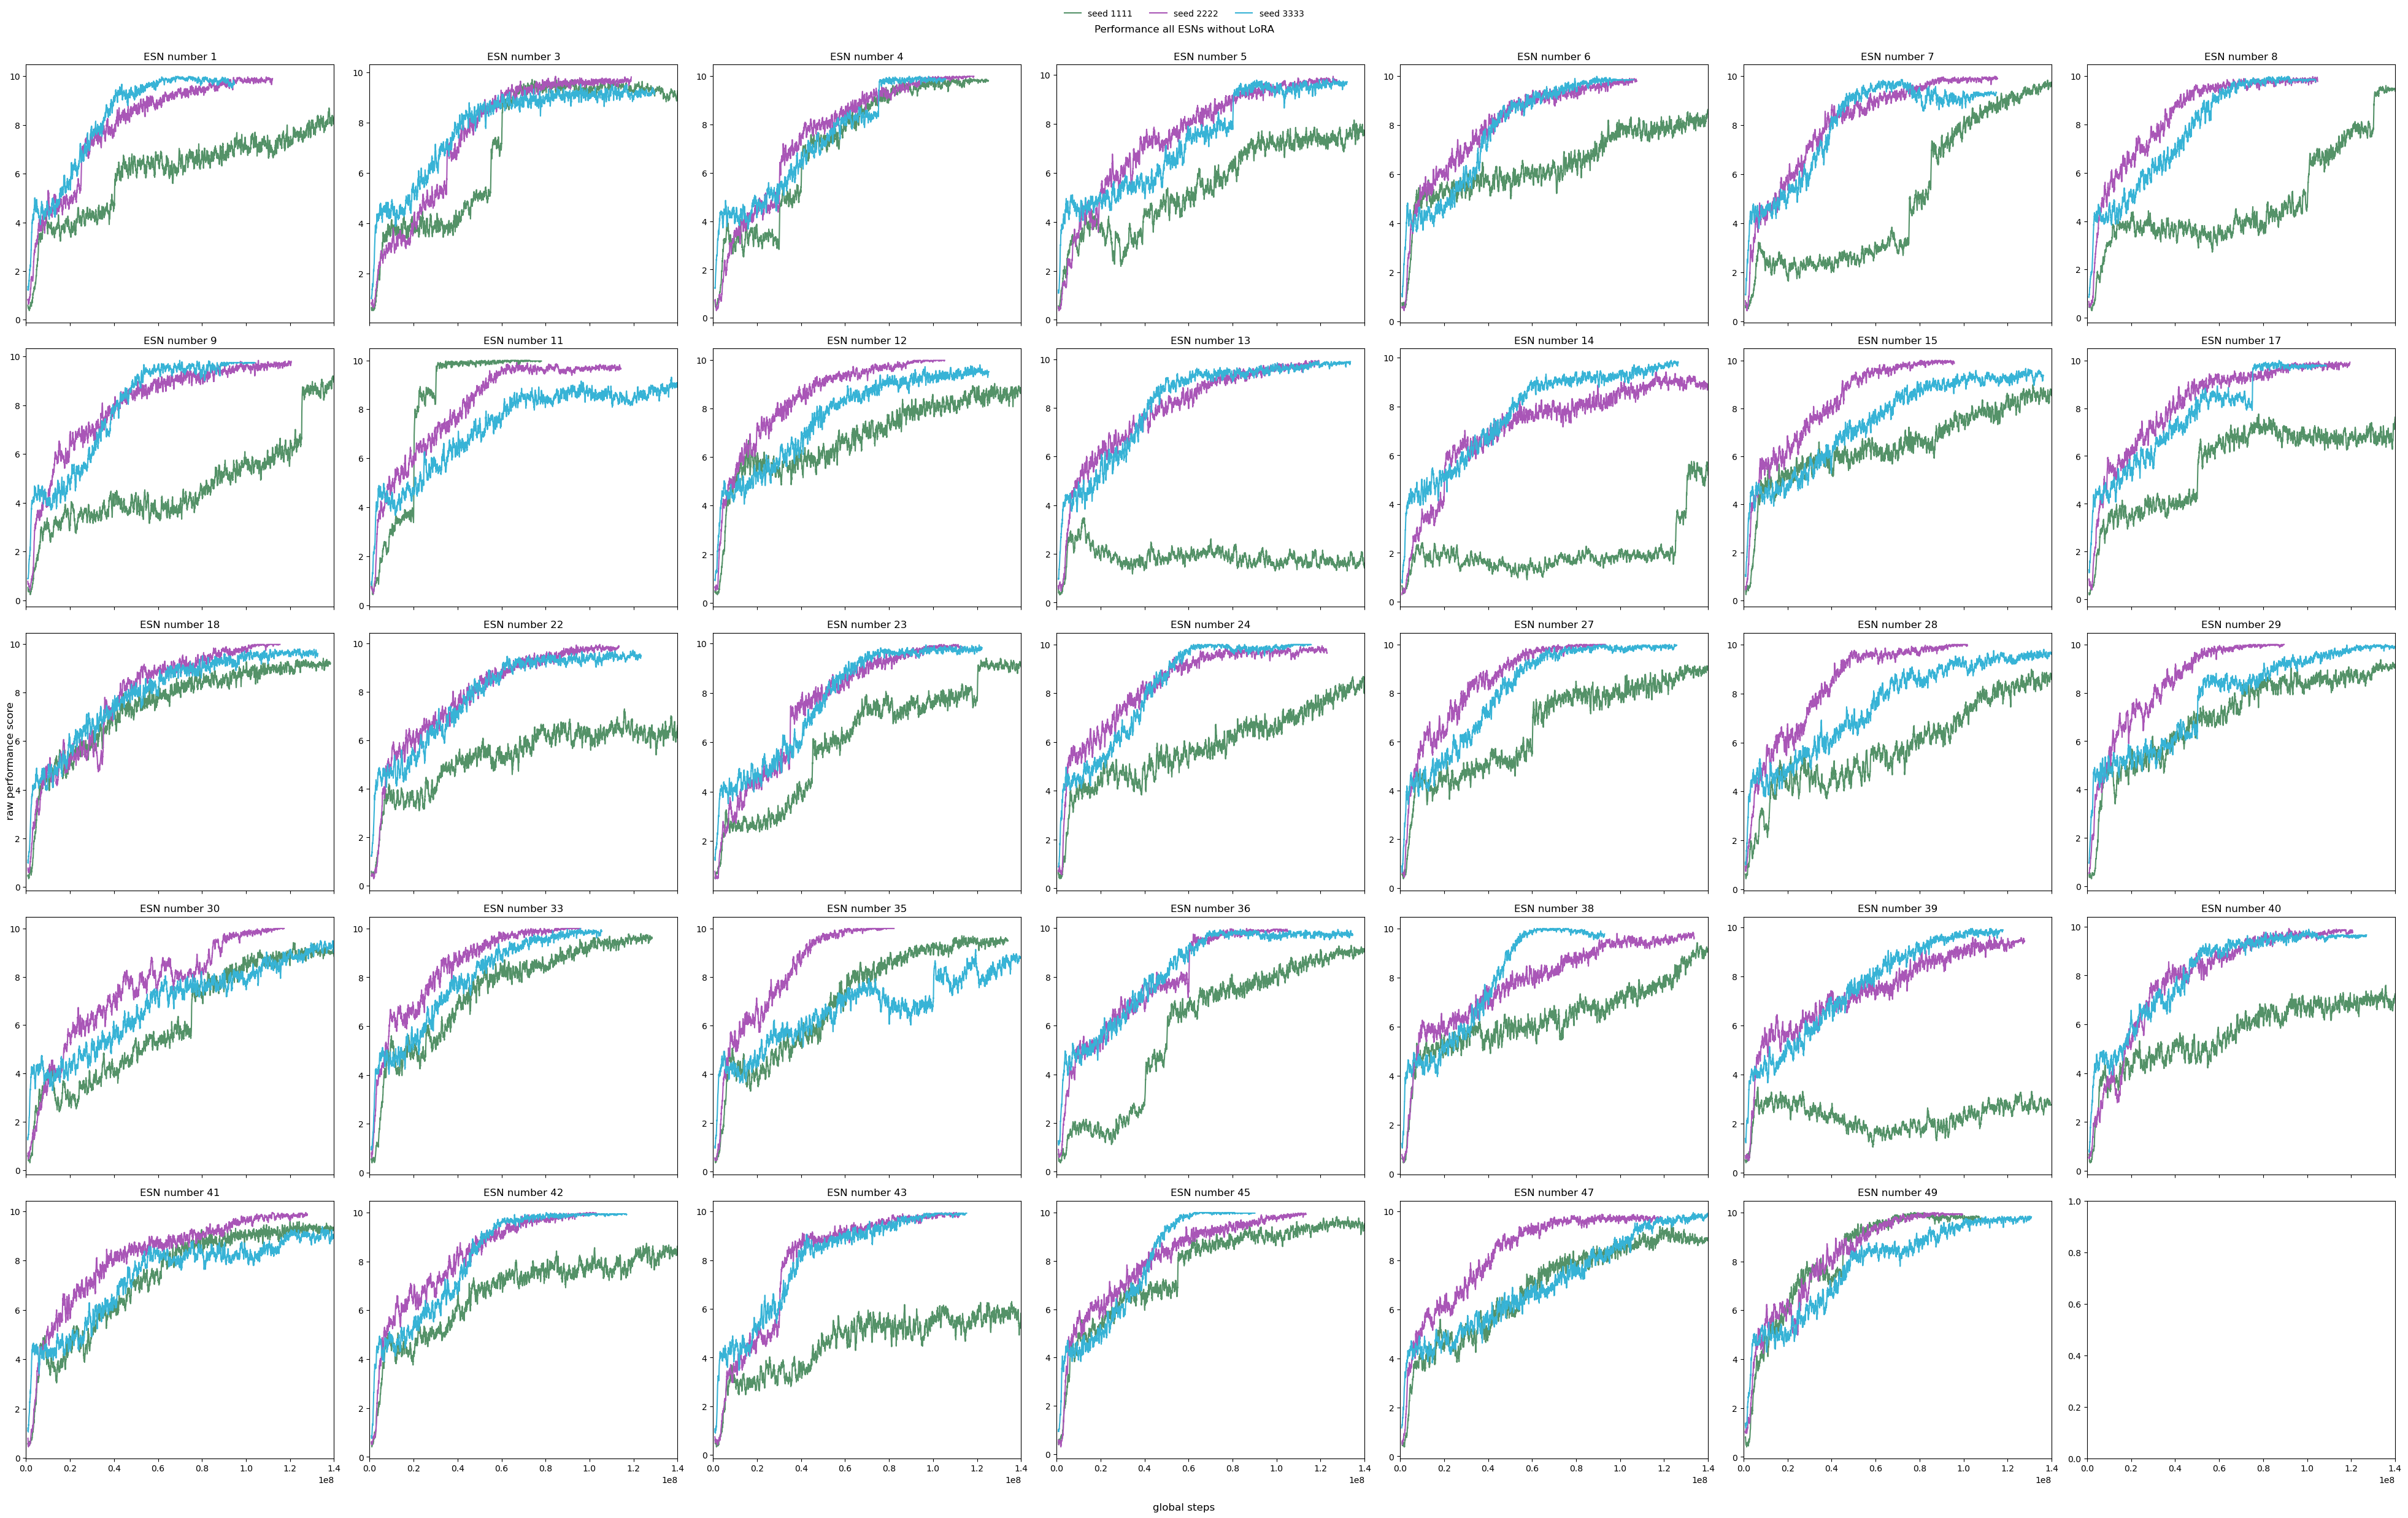

In [6]:
colors = ["#549268", '#a956b7', "#37B3D6"]

fig, ax = plt.subplots(5,7, figsize=(40,25), sharex=True)
for i,t in enumerate(weight_trials):
    for j,seed in enumerate(seeds):
        raw_score = mean_results[t][seed]['raw_score']
        idx = mean_results[t][seed]['raw_score'].index.to_list()
        ax[i//7, i%7].plot(idx, raw_score, c=colors[j], label=f"seed {seed}")
        ax[i//7, i%7].set_title(f'ESN number {t}')
        ax[i//7, i%7].set_xlim(0,1.4e8)

handles, labels = ax[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(seeds), frameon=False,
           bbox_to_anchor=(0.5, 0.995))

fig.supxlabel("global steps")   
fig.supylabel("raw performance score") 

fig.suptitle("Performance all ESNs without LoRA")

fig.tight_layout(rect=[0.01, 0.01, 1, 0.98]) 

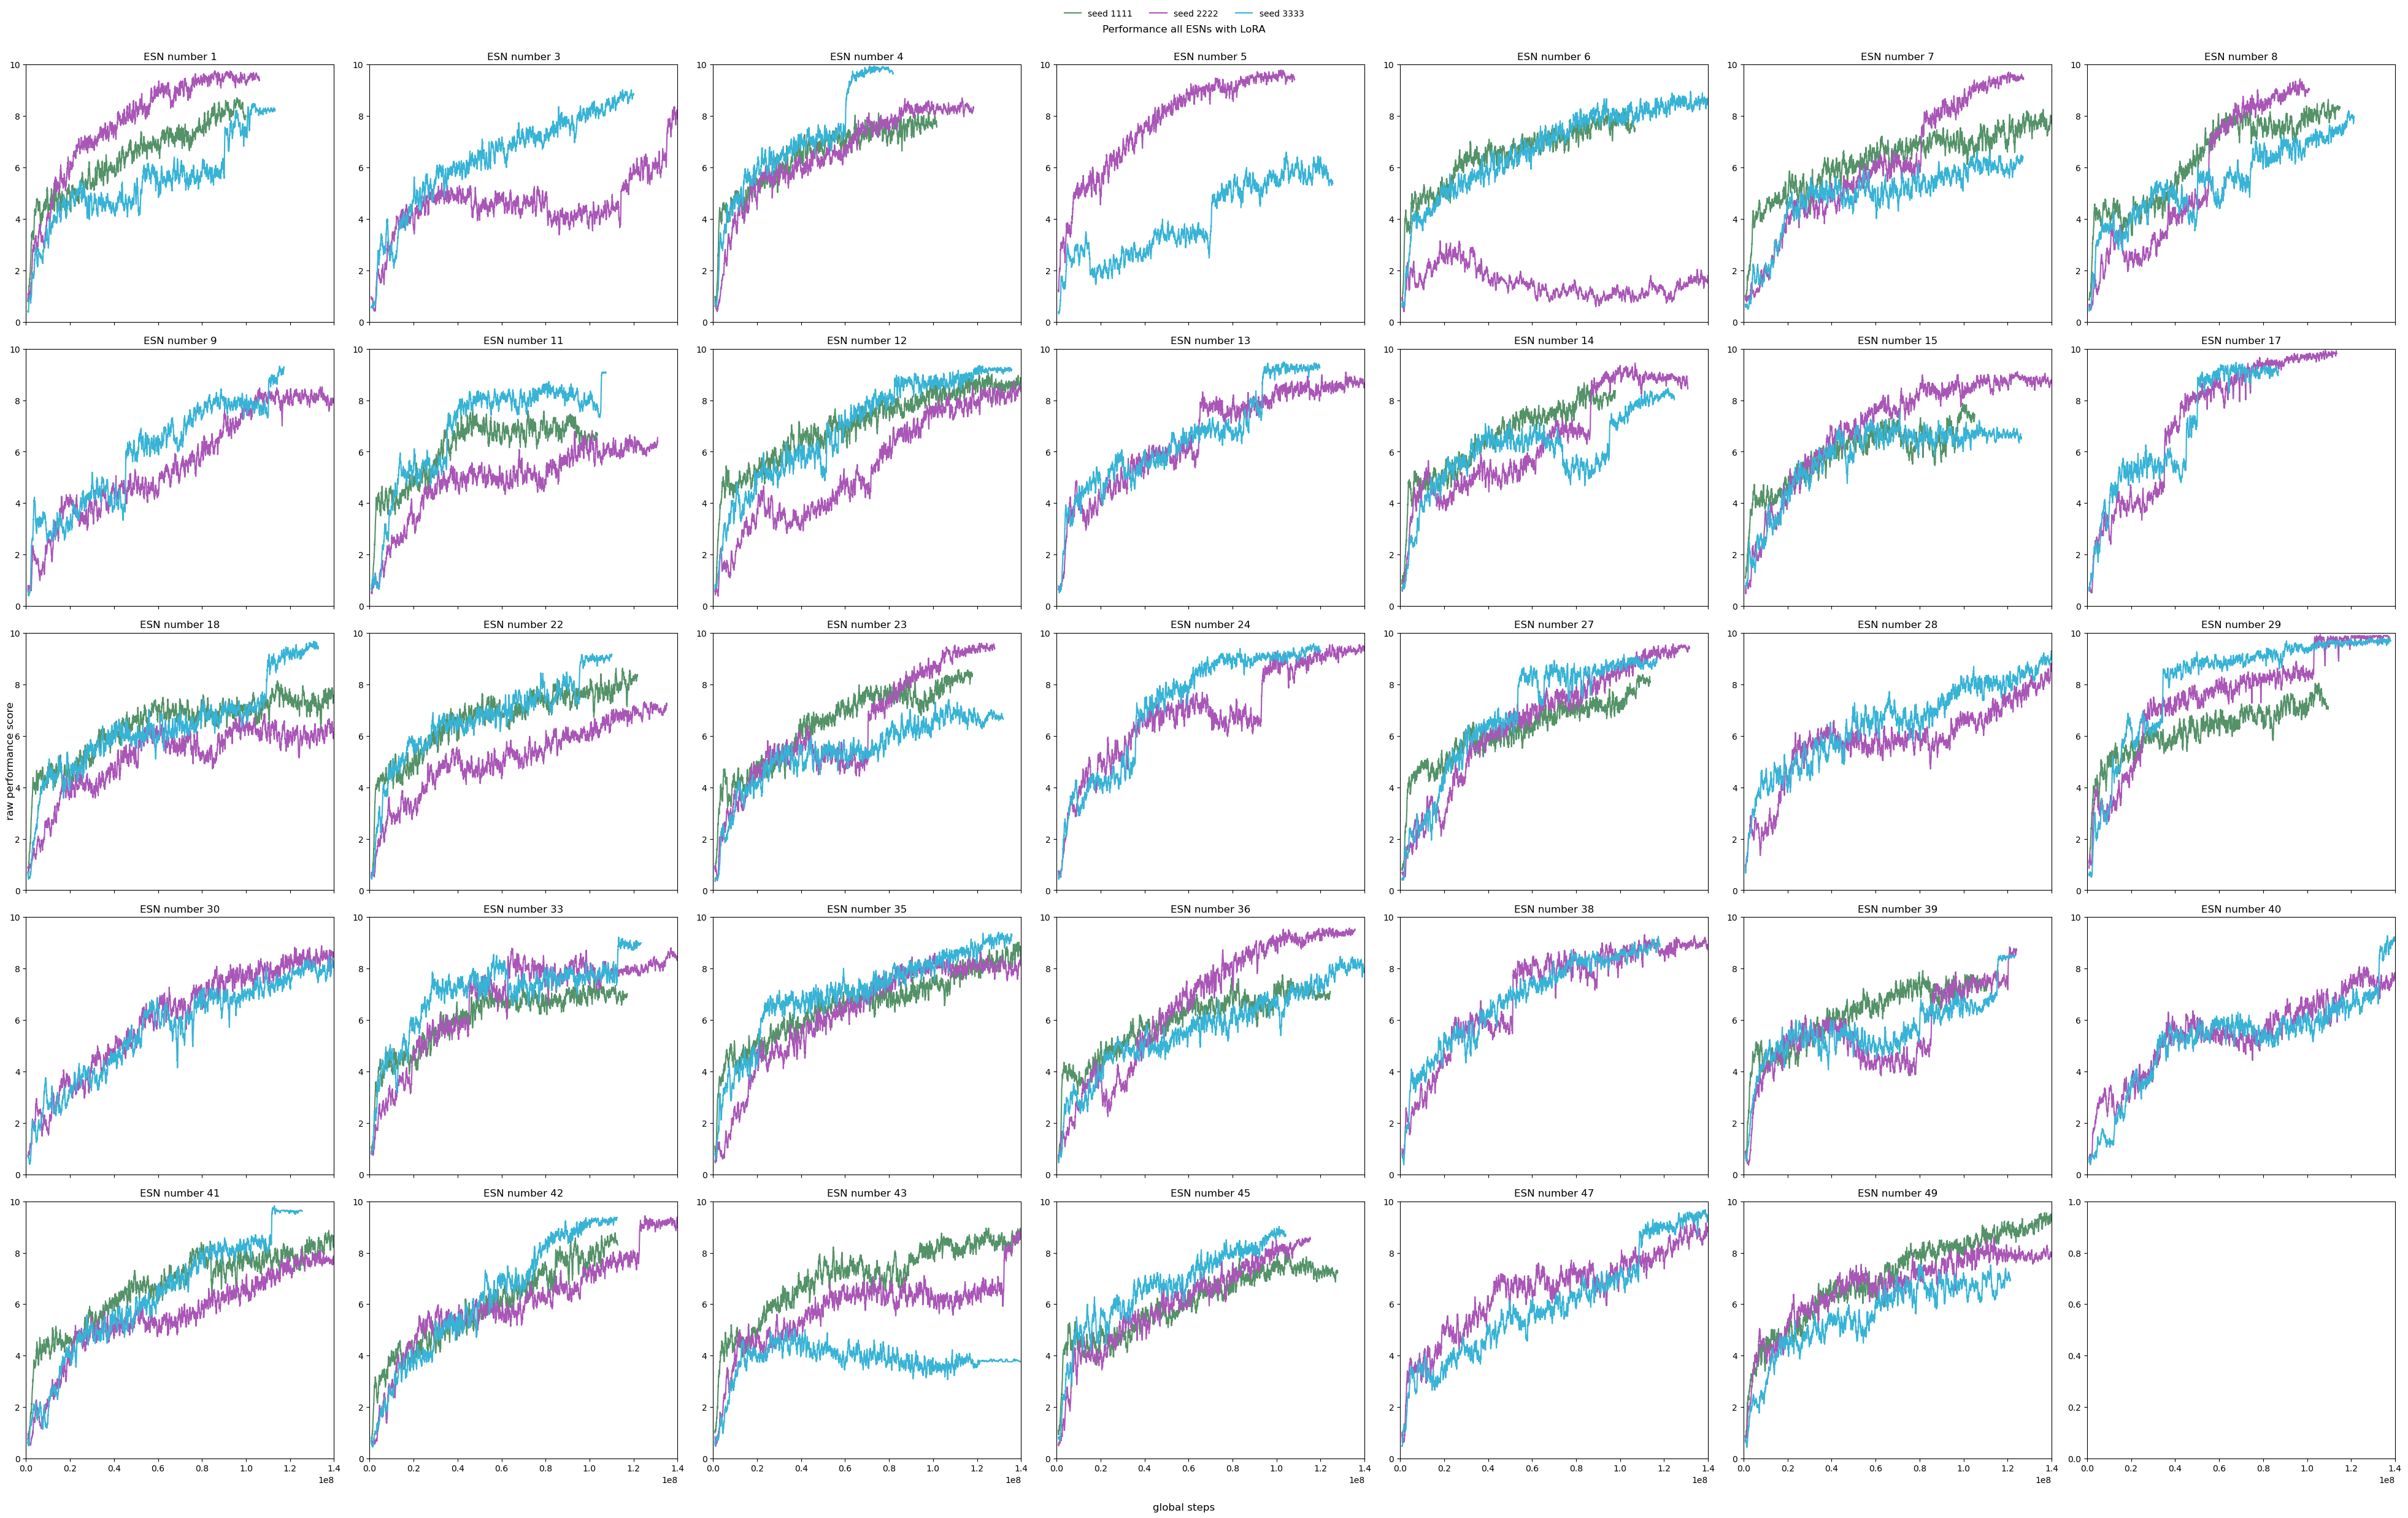

In [7]:
fig, ax = plt.subplots(5,7, figsize=(40,25), sharex=True)
for i,t in enumerate(weight_trials):
    for j,seed in enumerate(seeds):
        raw_score = mean_results_lora[t][seed]['raw_score']
        s = mean_results_lora[t][seed]['raw_score']
        if s is None or s.empty:
            mean_results_lora[t][seed] = np.nan
            continue                 
        idx = mean_results_lora[t][seed]['raw_score'].index.to_list()
        ax[i//7, i%7].plot(idx, raw_score, c=colors[j], label=f"seed {seed}")
        ax[i//7, i%7].set_title(f'ESN number {t}')
        ax[i//7, i%7].set_ylim(0,10)
        ax[i//7, i%7].set_xlim(0,1.4e8)

handles, labels = ax[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(seeds), frameon=False,
           bbox_to_anchor=(0.5, 0.995))

fig.supxlabel("global steps")   
fig.supylabel("raw performance score") 

fig.suptitle("Performance all ESNs with LoRA")

fig.tight_layout(rect=[0.01, 0.01, 1, 0.98]) 

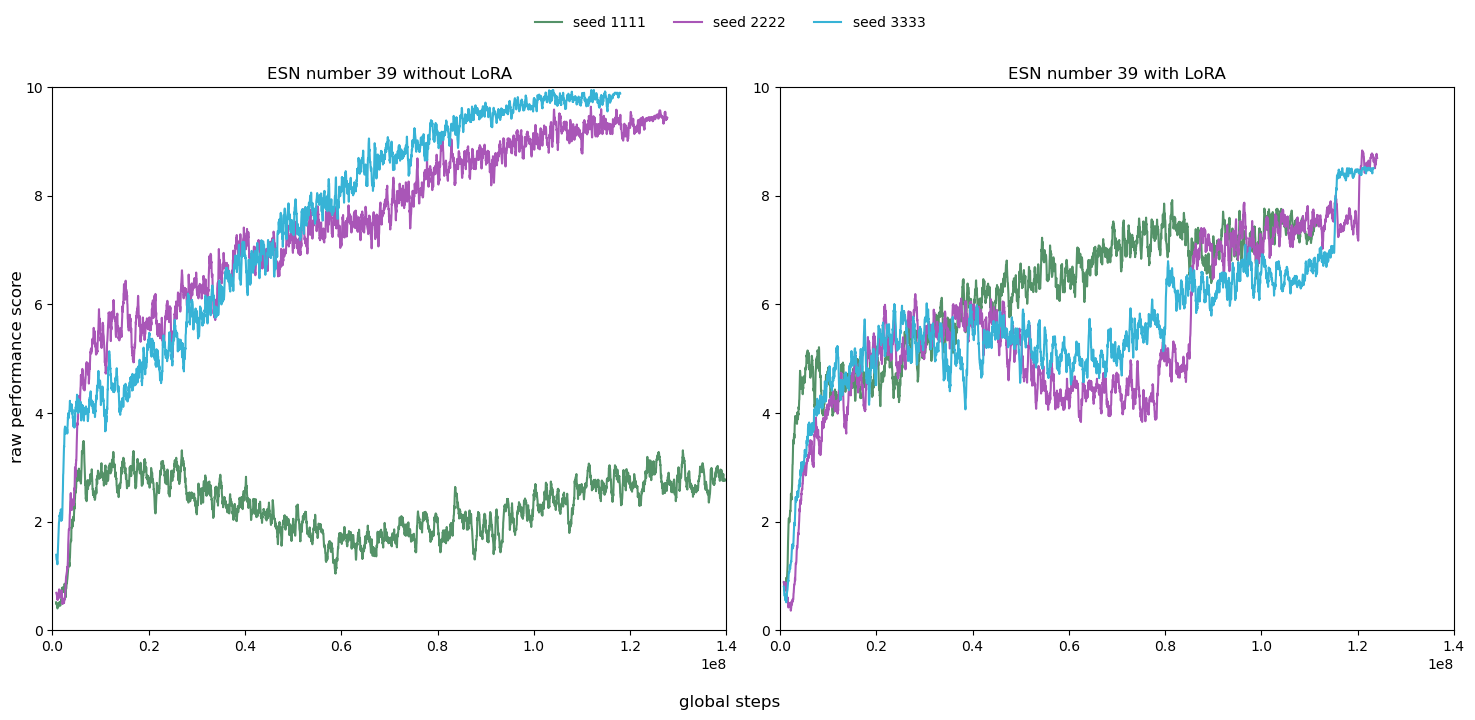

In [8]:
colors = ["#549268", '#a956b7', "#37B3D6"]


fig, ax = plt.subplots(1,2, figsize=(15,7), sharex=True)
for j,seed in enumerate(seeds):
    raw_score = mean_results_lora[39][seed]['raw_score']
    s = mean_results_lora[39][seed]['raw_score']
    if s is None or s.empty:
        mean_results_lora[39][seed] = np.nan
        continue                 
    idx = mean_results_lora[39][seed]['raw_score'].index.to_list()
    ax[1].plot(idx, raw_score, c=colors[j], label=f"seed {seed}")
    ax[1].set_title(f'ESN number {39} with LoRA')
    ax[1].set_xlim(0,1.4e8)
    ax[1].set_ylim(0,10)

    raw_score = mean_results[39][seed]['raw_score']
    idx = mean_results[39][seed]['raw_score'].index.to_list()
    ax[0].plot(idx, raw_score, c=colors[j], label=f"seed {seed}")
    ax[0].set_title(f'ESN number {39} without LoRA')
    ax[0].set_xlim(0,1.4e8)
    ax[0].set_ylim(0,10)

# one overarching legend for both plots
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(seeds), frameon=False,
           bbox_to_anchor=(0.5, 1.02))

fig.supxlabel("global steps")   
fig.supylabel("raw performance score") 

fig.tight_layout(rect=[0, 0, 1, 0.95]) 


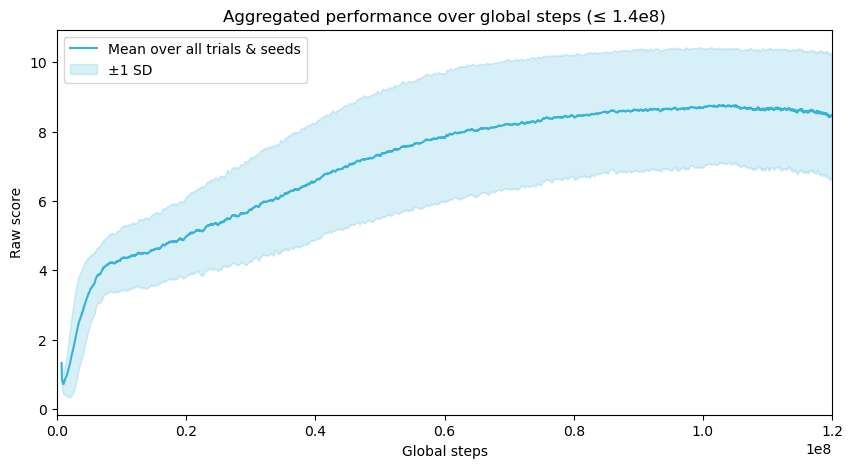

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# mean_results[t][seed]['raw_score'] ist (vermutlich) eine pd.Series
# mit Index = global steps, Values = performance/raw_score

records = []
for t in weight_trials:
    for seed in seeds:
        s = mean_results[t][seed]['raw_score']
        df = s.rename("raw_score").reset_index()
        df.columns = ["global_step", "raw_score"]
        df["weight_trial"] = t
        df["seed"] = seed
        records.append(df)

all_df = pd.concat(records, ignore_index=True)

# nur bis 1.4e8
max_step = 1.2e8
all_df = all_df[all_df["global_step"] <= max_step]

# Aggregation über alle Runs pro global_step:
agg = (all_df
       .groupby("global_step")["raw_score"]
       .agg(mean="mean", std="std", n="count")
       .reset_index()
       .sort_values("global_step"))

x = agg["global_step"].to_numpy()
y = agg["mean"].to_numpy()
sd = agg["std"].to_numpy()

color = "#37B3D6"

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, y, color=color, label="Mean over all trials & seeds")
ax.fill_between(x, y - sd, y + sd, color=color, alpha=0.2, label="±1 SD")

ax.set_xlim(0, max_step)
ax.set_xlabel("Global steps")
ax.set_ylabel("Raw score")
ax.set_title("Aggregated performance over global steps (≤ 1.4e8)")
ax.legend()
plt.show()



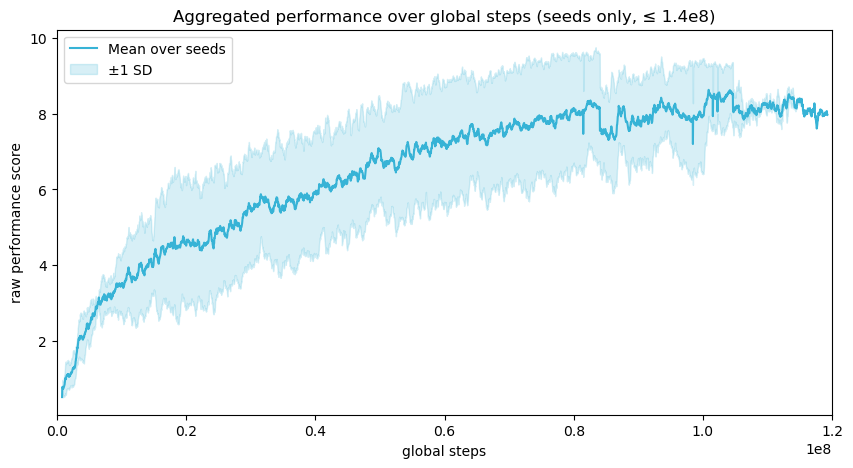

In [10]:
with open("/home/fr/fr_lr554/samplefactory/sample-factory/sf_workingdir_lilly/dmlab/analysis/data/sim46.pkl", "rb") as f:
    all_results_rnn = pickle.load(f)

weight_trials_rnn = [0]
n_seeds_rnn = 4
seeds_rnn = [2222, 3333, 4444, 5555]
n_policies_rnn = 4

sorted_weight_trials = sorted(weight_trials)

time_interval_rnn = [80000000,100000000]

mean_results_by_seeds_rnn = {2222:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None}, 
            3333:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None}, 
            4444:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None},
            5555:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None}}
for seed in seeds_rnn:
    mean_results_by_seeds_rnn[seed]['raw_score'] = all_results_rnn[seed]['raw_score'].mean(axis=1)
    mean_results_by_seeds_rnn[seed]['lenweighted_score'] = all_results_rnn[seed]['lenweighted_score'].mean(axis=1)
    mean_results_by_seeds_rnn[seed]['reward_min'] = all_results_rnn[seed]['reward_min'].mean(axis=1)
    mean_results_by_seeds_rnn[seed]['len'] = all_results_rnn[seed]['len'].mean(axis=1)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Sammle alle Seed-Kurven in ein gemeinsames DataFrame
records_rnn = []
for seed in seeds_rnn:
    s_rnn = mean_results_by_seeds_rnn[seed]["raw_score"]  # pd.Series: index=global_step, values=raw_score
    df_rnn = s_rnn.rename("raw_score").reset_index()
    df_rnn.columns = ["global_step", "raw_score"]
    df_rnn["seed"] = seed
    records_rnn.append(df_rnn)

all_df_rnn = pd.concat(records_rnn, ignore_index=True)

# nur bis 1.4e8
max_step_rnn = 1.2e8
all_df_rnn = all_df_rnn[all_df_rnn["global_step"] <= max_step_rnn]

# Aggregation über alle Seeds pro global_step:
agg_rnn = (all_df_rnn
       .groupby("global_step")["raw_score"]
       .agg(mean="mean", std="std", n="count")
       .reset_index()
       .sort_values("global_step"))

x_rnn = agg_rnn["global_step"].to_numpy()
y_rnn = agg_rnn["mean"].to_numpy()
sd_rnn = agg_rnn["std"].to_numpy()

color = "#37B3D6"

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_rnn, y_rnn, color=color, label="Mean over seeds")
ax.fill_between(x_rnn, y_rnn - sd_rnn, y_rnn + sd_rnn, color=color, alpha=0.2, label="±1 SD")

ax.set_xlim(0, max_step_rnn)
ax.set_xlabel("global steps")
ax.set_ylabel("raw performance score")
ax.set_title("Aggregated performance over global steps (seeds only, ≤ 1.4e8)")
ax.legend()
plt.show()
    

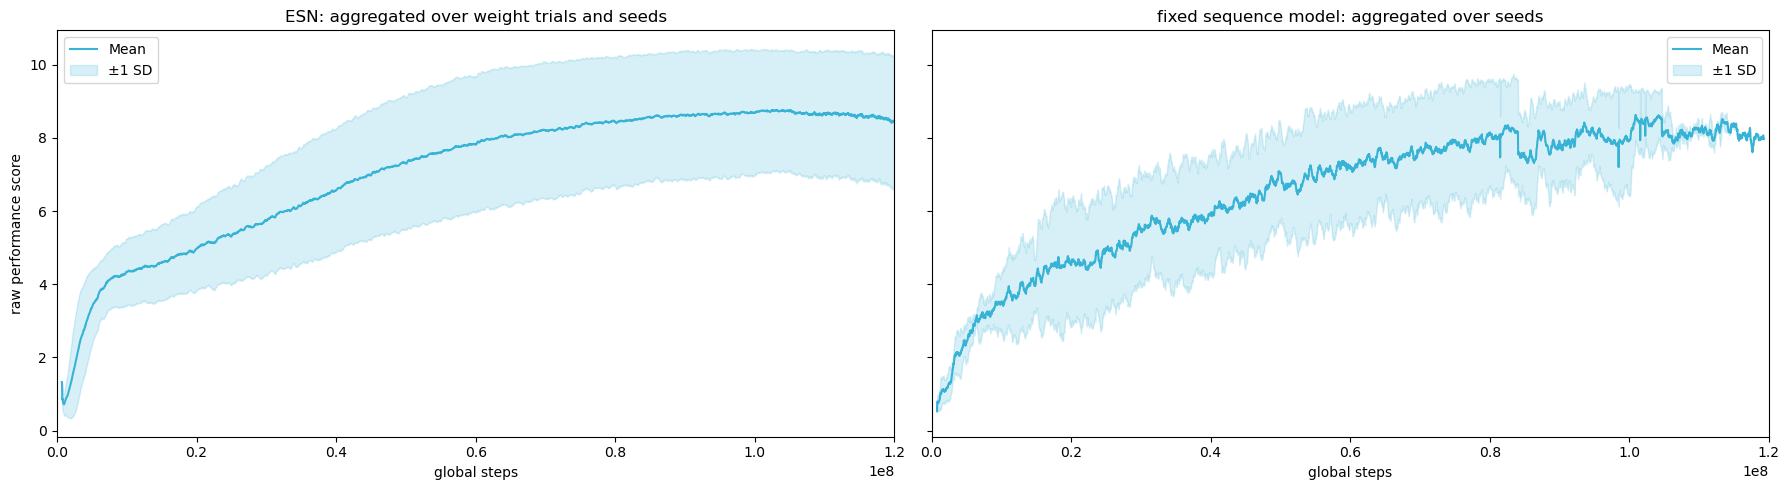

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

color = "#37B3D6"
max_step = 1.2e8
max_step_rnn = 1.2e8

# ---------------------------
# (1) ESN: all trials & seeds
# ---------------------------
records = []
for t in weight_trials:
    for seed in seeds:
        s = mean_results[t][seed]["raw_score"]  # pd.Series
        df = s.rename("raw_score").reset_index()
        df.columns = ["global_step", "raw_score"]
        df["weight_trial"] = t
        df["seed"] = seed
        records.append(df)

all_df = pd.concat(records, ignore_index=True)
all_df = all_df[all_df["global_step"] <= max_step]

agg = (all_df.groupby("global_step")["raw_score"]
       .agg(mean="mean", std="std", n="count")
       .reset_index()
       .sort_values("global_step"))

x = agg["global_step"].to_numpy()
y = agg["mean"].to_numpy()
sd = agg["std"].to_numpy()

# ---------------------------
# (2) RNN: seeds from sim46.pkl
# ---------------------------
with open("/home/fr/fr_lr554/samplefactory/sample-factory/sf_workingdir_lilly/dmlab/analysis/data/sim46.pkl", "rb") as f:
    all_results_rnn = pickle.load(f)

seeds_rnn = [2222, 3333, 4444, 5555]

mean_results_by_seeds_rnn = {seed: {} for seed in seeds_rnn}
for seed in seeds_rnn:
    mean_results_by_seeds_rnn[seed]["raw_score"] = all_results_rnn[seed]["raw_score"].mean(axis=1)

records_rnn = []
for seed in seeds_rnn:
    s_rnn = mean_results_by_seeds_rnn[seed]["raw_score"]  # pd.Series
    df_rnn = s_rnn.rename("raw_score").reset_index()
    df_rnn.columns = ["global_step", "raw_score"]
    df_rnn["seed"] = seed
    records_rnn.append(df_rnn)

all_df_rnn = pd.concat(records_rnn, ignore_index=True)
all_df_rnn = all_df_rnn[all_df_rnn["global_step"] <= max_step_rnn]

agg_rnn = (all_df_rnn.groupby("global_step")["raw_score"]
           .agg(mean="mean", std="std", n="count")
           .reset_index()
           .sort_values("global_step"))

x_rnn = agg_rnn["global_step"].to_numpy()
y_rnn = agg_rnn["mean"].to_numpy()
sd_rnn = agg_rnn["std"].to_numpy()

# ---------------------------
# Side-by-side plot
# ---------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=True)

# Left: ESN aggregated
axes[0].plot(x, y, color=color, label="Mean")
axes[0].fill_between(x, y - sd, y + sd, color=color, alpha=0.2, label="±1 SD")
axes[0].set_xlim(0, max_step)
axes[0].set_xlabel("global steps")
axes[0].set_ylabel("raw performance score")
axes[0].set_title("ESN: aggregated over weight trials and seeds")
axes[0].legend()

# Right: RNN aggregated
axes[1].plot(x_rnn, y_rnn, color=color, label="Mean")
axes[1].fill_between(x_rnn, y_rnn - sd_rnn, y_rnn + sd_rnn, color=color, alpha=0.2, label="±1 SD")
axes[1].set_xlim(0, max_step_rnn)
axes[1].set_xlabel("global steps")
axes[1].set_title("fixed sequence model: aggregated over seeds")
axes[1].legend()

plt.tight_layout()
plt.show()


In [12]:
mean_raw_score_time_interval = dict()
for i, trial in enumerate(weight_trials):
    mean_raw_score_time_interval[trial] = dict()
    for seed in seeds:
        raw_score = mean_results[trial][seed]['raw_score']
        raw_score_time_interval = raw_score[time_interval[0]:time_interval[1]]
        mean_raw_score_time_interval[trial][seed] = raw_score_time_interval.mean()

/tmp/ipykernel_3334435/227449889.py:6: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  raw_score_time_interval = raw_score[time_interval[0]:time_interval[1]]


In [13]:
mean_raw_score_time_interval_lora = dict()
for i, trial in enumerate(weight_trials):
    mean_raw_score_time_interval_lora[trial] = dict()
    for seed in seeds_lora:
        raw_score = mean_results_lora[trial][seed]['raw_score']
        s = mean_results_lora[trial][seed]['raw_score']
        if s is None or s.empty:
            mean_raw_score_time_interval_lora[trial][seed] = np.nan
            continue
        last_idx = s.index[-1]
        if last_idx<80000000:
            mean_raw_score_time_interval_lora[trial][seed] = s[s.index[-1]]
            continue
        raw_score_time_interval = raw_score[time_interval[0]:time_interval[1]]
        mean_raw_score_time_interval_lora[trial][seed] = raw_score_time_interval.mean()

TypeError: 'float' object is not subscriptable

In [ ]:
raw_score = mean_results_lora[trial][seed]['raw_score']
print(raw_score[time_interval[0]:time_interval[1]])

80010000.0    7.525000
80040000.0    7.627083
80070000.0    7.725000
80100000.0    7.730000
80130000.0    7.739583
                ...   
99870000.0    8.587500
99900000.0    8.504167
99930000.0    8.520833
99960000.0    8.441667
99990000.0    8.410000
Length: 667, dtype: float64


/tmp/ipykernel_2167459/679461915.py:2: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  print(raw_score[time_interval[0]:time_interval[1]])


In [ ]:
print(mean_raw_score_time_interval.keys())
print(mean_raw_score_time_interval_lora[1][1111])
mean_raw_score_time_interval[1][1111]

dict_keys([1, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 17, 18, 22, 23, 24, 27, 28, 29, 30, 33, 35, 36, 38, 39, 40, 41, 42, 43, 45, 47, 49])
8.494708232506554


np.float64(6.898100324837582)

In [ ]:
print(mean_raw_score_time_interval_lora.keys())
mean_raw_score_time_interval_lora[1].keys()

dict_keys([1, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 17, 18, 22, 23, 24, 27, 28, 29, 30, 33, 35, 36, 38, 39, 40, 41, 42, 43, 45, 47, 49])


dict_keys([1111, 2222, 3333, 4444, 5555])

In [ ]:
performance = np.zeros((len(seeds), len(weight_trials)))

for t_i, t in enumerate(weight_trials):
    for s_i,seed in enumerate(seeds):
        performance[s_i,t_i] = mean_raw_score_time_interval[t][seed]

In [ ]:
performance_lora = np.zeros((len(seeds_lora), len(weight_trials)))

for t_i, t in enumerate(weight_trials):
    for s_i,seed in enumerate(seeds_lora):
        performance_lora[s_i,t_i] = mean_raw_score_time_interval_lora[t][seed]

In [ ]:
print(performance_lora.shape)
performance_lora = performance_lora[:3,]
print(performance_lora.shape)
performance_lora_mean = np.nanmean(performance_lora, axis=0)
print(performance_lora_mean.shape)

(5, 34)
(3, 34)
(34,)


In [ ]:
print(performance.shape)
performance_mean      = np.nanmean(performance, axis=0)
print(performance_mean.shape)

(3, 34)
(34,)


In [ ]:
d = performance_lora_mean - performance_mean
print("Mean difference:", np.nanmean(d))
print("Median difference:", np.nanmedian(d))

Mean difference: -0.43857015700269547
Median difference: -0.5356424518511584


In [ ]:
print(performance_mean)
print(performance_lora_mean)

[8.793838   9.36854077 9.67802123 8.55720452 8.81670867 8.54379853
 8.03692666 8.03872949 9.1350047  8.94747863 6.89437039 6.40274298
 8.6303098  8.78876893 9.15629818 8.39517338 8.88441134 8.67459383
 9.23719016 8.42931374 9.16278812 8.34946867 9.53409186 8.56156612
 9.10538363 8.57809114 6.72830317 8.56303421 8.80894037 9.13772585
 8.19492865 9.5222695  8.64479459 9.63774413]
[8.69516982 7.91666698 8.37500554 7.68284415 7.85619125 8.26476325
 8.43006052 8.69717926 8.04071135 8.85152594 8.40450782 7.95144642
 7.90413888 8.4229567  8.22650169 7.89252875 8.33164326 9.13158289
 7.82601836 8.3119882  8.01397891 7.48867716 8.74269383 8.009017
 8.74352609 8.49709139 7.34306349 8.25862865 8.07006811 7.92150007
 7.97490289 8.13807273 7.49350893 9.11900835]


In [ ]:
d = performance_lora_mean - performance_mean
n = d.size

print(f"n = {n}")
print(f"Mean difference (base - Lora): {d.mean():.6g}")
print(f"Median difference: {np.median(d):.6g}")

# paired t-test
t_stat, p_two = stats.ttest_rel(performance_lora_mean, performance_mean, nan_policy="omit")
p_one = p_two / 2 if t_stat > 0 else 1 - p_two / 2
print("\nPaired t-test (H1: LoRA > base)")
print(f"t = {t_stat:.4f}, p(one-sided) = {p_one:.4g}, p(two-sided) = {p_two:.4g}")

n = 34
Mean difference (base - Lora): -0.43857
Median difference: -0.535642

Paired t-test (H1: LoRA > base)
t = -3.3705, p(one-sided) = 0.999, p(two-sided) = 0.001925


In [ ]:
d

array([-0.09866818, -1.45187378, -1.30301569, -0.87436037, -0.96051742,
       -0.27903528,  0.39313386,  0.65844976, -1.09429335, -0.09595269,
        1.51013743,  1.54870343, -0.72617091, -0.36581223, -0.92979649,
       -0.50264464, -0.55276808,  0.45698906, -1.41117181, -0.11732554,
       -1.14880921, -0.86079151, -0.79139803, -0.55254912, -0.36185754,
       -0.08099975,  0.61476032, -0.30440557, -0.73887225, -1.21622578,
       -0.22002576, -1.38419678, -1.15128566, -0.51873579])

In [ ]:
d = performance_lora_mean - performance_mean   # positive => LoRA better


In [ ]:
t_stat, p_two = stats.ttest_rel(performance_lora_mean, performance_mean, nan_policy="omit")


In [ ]:
# Summary + direction
mean_diff = np.mean(d)
median_diff = np.median(d)

direction = "LoRA > base" if mean_diff > 0 else "base > LoRA" if mean_diff < 0 else "no mean difference"

print(f"Mean(LoRA - base) = {mean_diff:.6g}")
print(f"Median(LoRA - base) = {median_diff:.6g}")
print(f"Two-sided paired t-test: t = {t_stat:.4f}, p = {p_two:.6g}")
print(f"Direction by mean difference: {direction}")


Mean(LoRA - base) = -0.43857
Median(LoRA - base) = -0.535642
Two-sided paired t-test: t = -3.3705, p = 0.00192531
Direction by mean difference: base > LoRA


In [ ]:
d_not_mean = performance_lora - performance
d_trial = np.nanmean(d_not_mean, axis=0) 
t_stat, p_two = stats.ttest_1samp(d_trial, 0.0, nan_policy="omit")
print(t_stat, p_two)
print("mean diff (LoRA-base):", np.nanmean(d_trial))

-3.3093086766159616 0.0022686901788730564
mean diff (LoRA-base): -0.42630180210922203


In [ ]:
d_not_mean = performance_lora - performance
#d_trial = np.nanmean(d_not_mean, axis=0) 
t_stat, p_two = stats.ttest_1samp(d_not_mean.T, 0.0, nan_policy="omit")
print(t_stat, p_two)
print("mean diff (LoRA-base):", np.nanmean(d_trial))

[  3.36381649  -7.47986025 -10.72107482] [2.00796415e-03 1.34192115e-08 2.75233276e-12]
mean diff (LoRA-base): -0.42630180210922203


In [ ]:
loramin=performance_lora.min(axis=0)
noloramin=performance.min(axis=0)
t_stat, p_two = stats.ttest_1samp(loramin-noloramin, 0.0, nan_policy="omit")
print(t_stat, p_two)
print("mean diff (LoRA-base):", np.nanmean(loramin-noloramin))

2.1812575633864015 0.03662467044612967
mean diff (LoRA-base): 0.7887020767629154


In [ ]:
lorastd=performance_lora.std(axis=0)
nolorastd=performance.std(axis=0)
t_stat, p_two = stats.ttest_1samp(lorastd-nolorastd, 0.0, nan_policy="omit")
print(t_stat, p_two)
print("mean diff (LoRA-base):", np.nanmean(lorastd-nolorastd))

-4.6806765812977815 5.015099519719768e-05
mean diff (LoRA-base): -0.8054209648529663
